# GaussianHead
Here  we will breakdown the [GaussianHead's](https://github.com/chiehwangs/gaussian-head) inderence

## Input Data
First, let's check how input data is prepared

In [1]:
from src.gs.dataset_readers import readNeRFBlendShapeDataset

source_path = "data/id1"
scene_info = readNeRFBlendShapeDataset(source_path, False, False, False, False)

Load NeRFBlendShape Train Dataset
Loading train dataset from data/id1...


Loading data into memory in advance: 100%|█████████████████████████████████████████| 2254/2254 [00:29<00:00, 77.67it/s]


Load NeRFBlendShape Test Dataset
Loading train dataset from data/id1...


Loading data into memory in advance: 100%|█████████████████████████████████████████| 2254/2254 [00:26<00:00, 83.57it/s]


In [2]:
scene_info.point_cloud.points.shape

(10000, 3)

Let's check initialization points are random

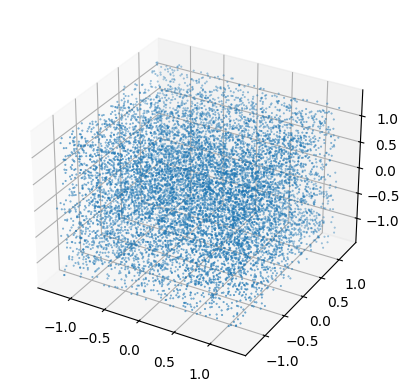

In [5]:
import matplotlib.pyplot as plt
points = scene_info.point_cloud.points
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=0.2)
plt.show()

Now, Let's check trained model's point cloud

In [3]:
from src.gs.model import GaussianModel

gaussians = GaussianModel(sh_degree=3)
trained_gaussians_path = "output/id1/point_cloud/iteration_80000/point_cloud.ply"
gaussians.load_ply(trained_gaussians_path, og_number_points=len(scene_info.point_cloud.points))

In [4]:
gaussians._xyz.shape

torch.Size([182720, 3])

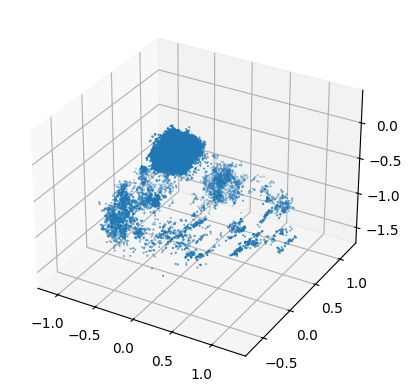

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
gaussian_means = gaussians._xyz.detach().cpu().numpy()
ax.scatter(gaussian_means[:, 0], gaussian_means[:, 1], gaussian_means[:, 2], s=0.2)
plt.show()

In [12]:
# expression is stored in camera info, so be don't need to build camer object for now
exp = scene_info.train_cameras[0].exp

In [22]:
exp.shape[0]

46

## Deformation Model
Now, see what's deformation model does excactly.
As input it takes gaussians' means and expression.
As a result it should return position, scaling and rotation deltas.
First, let's just load model from a checkpoint.

In [24]:
from src.models.deform_model import DeformNetwork

deform = DeformNetwork(exp.shape[0])

In [49]:
import torch
# load weights
weights_path = "output/id1/deform/iteration_80000/deform.pth"
deform.load_state_dict(torch.load(weights_path))
deform.to("cuda")

DeformNetwork(
  (linear): ModuleList(
    (0): Linear(in_features=109, out_features=256, bias=True)
    (1-4): 4 x Linear(in_features=256, out_features=256, bias=True)
    (5): Linear(in_features=365, out_features=256, bias=True)
    (6-7): 2 x Linear(in_features=256, out_features=256, bias=True)
  )
  (gaussian_warp): Linear(in_features=256, out_features=3, bias=True)
  (gaussian_rotation): Linear(in_features=256, out_features=4, bias=True)
  (gaussian_scaling): Linear(in_features=256, out_features=3, bias=True)
)

Then cunduct `forward` by steps

In [55]:
# first let's get embeddings from position and expression
xyz = gaussians.get_xyz.detach()
exp_input = torch.tensor(exp, dtype=torch.float32, device=xyz.device).unsqueeze(0).expand(xyz.shape[0], -1) # don't forget to expand tensor to match the number of gaussians
deform.eval()
with torch.no_grad():
    e_emb = deform.embed_exp_fn(exp_input)
    x_emb = deform.embed_fn(xyz)

In [51]:
# check dimensions
e_emb.shape, x_emb.shape, deform.input_ch 

(torch.Size([182720, 46]), torch.Size([182720, 63]), 109)

In [56]:
# then just call feedforward layers (with skip connections) as in `forward` method
import torch.nn.functional as F
h = torch.cat([x_emb, e_emb], dim=-1)
for i, l in enumerate(deform.linear):
    h = deform.linear[i](h)
    h = F.relu(h)
    if i in deform.skips:
        h = torch.cat([x_emb, e_emb, h], -1)

h.shape

torch.Size([182720, 256])

In [57]:
# Finally, obtain deltas
d_xyz = deform.gaussian_warp(h)
d_scaling = deform.gaussian_scaling(h)
d_rotation = deform.gaussian_rotation(h)

Now let's build updated intermediate `core` gaussians to check them in external viewer

In [58]:
new_gaussians = GaussianModel(sh_degree=3)
new_gaussians._xyz = xyz + d_xyz
# Remember about activation funcions for some gaussians' properties
new_gaussians._scaling = new_gaussians.scaling_inverse_activation(gaussians.get_scaling + d_scaling) 
new_gaussians._rotation = gaussians.get_rotation + d_rotation
new_gaussians._opacity = gaussians._opacity
new_gaussians._features_dc = gaussians._features_dc
new_gaussians._features_rest = gaussians._features_rest

In [63]:
# save `core` gaussians (external methods to not reload the kernel)
import numpy as np
from plyfile import PlyData, PlyElement

def construct_list_of_attributes(gaussians):
    l = ['x', 'y', 'z', 'nx', 'ny', 'nz']
    # All channels except the 3 DC
    for i in range(gaussians._features_dc.shape[1] * gaussians._features_dc.shape[2]):
        l.append('f_dc_{}'.format(i))
    for i in range(gaussians._features_rest.shape[1] * gaussians._features_rest.shape[2]):
        l.append('f_rest_{}'.format(i))
    l.append('opacity')
    for i in range(gaussians._scaling.shape[1]):
        l.append('scale_{}'.format(i))
    for i in range(gaussians._rotation.shape[1]):
        l.append('rot_{}'.format(i))
    return l


def save_ply(gaussians, path):
    xyz = gaussians._xyz.detach().cpu().numpy()
    print("current number of gaussians:", xyz.shape[0])
    normals = np.zeros_like(xyz)
    f_dc = gaussians._features_dc.detach().transpose(1, 2).flatten(start_dim=1).contiguous().cpu().numpy()
    f_rest = gaussians._features_rest.detach().transpose(1, 2).flatten(start_dim=1).contiguous().cpu().numpy()
    opacities = gaussians._opacity.detach().cpu().numpy()
    scale = gaussians._scaling.detach().cpu().numpy()
    rotation = gaussians._rotation.detach().cpu().numpy()

    dtype_full = [(attribute, 'f4') for attribute in construct_list_of_attributes(gaussians)]

    elements = np.empty(xyz.shape[0], dtype=dtype_full)
    attributes = np.concatenate((xyz, normals, f_dc, f_rest, opacities, scale, rotation), axis=1)
    elements[:] = list(map(tuple, attributes))
    el = PlyElement.describe(elements, 'vertex')
    PlyData([el]).write(path)

save_ply(new_gaussians, 'core.ply')

current number of gaussians: 182720


## Tri-plane model
Next step is to apply tri-plane to update opacity and colors. 